In [1]:
import pandas as pd
import requests

AWS Region

In [2]:
aws_ip_url = "https://ip-ranges.amazonaws.com/ip-ranges.json"

aws_data = requests.get(aws_ip_url).json()

aws_regions = sorted({
    item["region"]
    for item in aws_data["prefixes"]
    if item.get("region") != "GLOBAL"
})

aws_regions_df = pd.DataFrame({
    "provider": "AWS",
    "region_code": aws_regions
})

aws_regions_df.shape

(42, 2)

In [3]:
aws_regions_df.head()

,provider,region_code
0,AWS,af-south-1
1,AWS,ap-east-1
2,AWS,ap-east-2
3,AWS,ap-northeast-1
4,AWS,ap-northeast-2


Azure Region

In [4]:
def fetch_azure_regions():
    url = "https://prices.azure.com/api/retail/prices"
    params = {
        "$filter": "serviceName eq 'Virtual Machines' and priceType eq 'Consumption'"
    }

    regions = set()

    while url:
        r = requests.get(url, params=params)
        r.raise_for_status()
        data = r.json()

        for item in data.get("Items", []):
            region = item.get("armRegionName")
            if region:
                regions.add(region)

        url = data.get("NextPageLink")
        params = None

    return pd.DataFrame({
        "provider": "Azure",
        "region_code": sorted(regions)
    })

azure_regions_df = fetch_azure_regions()

azure_regions_df.shape

(77, 2)

In [5]:
azure_regions_df.head()

,provider,region_code
0,Azure,Global
1,Azure,attatlanta1
2,Azure,attdallas1
3,Azure,attdetroit1
4,Azure,attnewyork1


GCP Region Data

In [6]:
GCP_API_KEY = "YOUR_GCP_API_KEY"
PROJECT_ID = "你的_GCP_PROJECT_ID"

In [8]:
gcp_regions = [
"us-central1",
"us-east1",
"us-east4",
"us-east5",
"us-south1",
"us-west1",
"us-west2",
"us-west3",
"us-west4",

"northamerica-northeast1",
"northamerica-northeast2",

"southamerica-east1",
"southamerica-west1",

"europe-central2",
"europe-north1",
"europe-southwest1",
"europe-west1",
"europe-west2",
"europe-west3",
"europe-west4",
"europe-west6",
"europe-west8",
"europe-west9",
"europe-west10",
"europe-west12",

"asia-east1",
"asia-east2",
"asia-northeast1",
"asia-northeast2",
"asia-northeast3",
"asia-south1",
"asia-south2",
"asia-southeast1",
"asia-southeast2",

"australia-southeast1",
"australia-southeast2",

"me-central1",
"me-central2",
"me-west1",

"africa-south1"
]

In [9]:
gcp_regions_df = pd.DataFrame({
    "provider":"GCP",
    "region_code":gcp_regions
})

gcp_regions_df.shape

(40, 2)

In [11]:
aws_regions_df.shape

(42, 2)

In [12]:
azure_regions_df.shape

(77, 2)

In [13]:
gcp_regions_df.shape

(40, 2)

In [14]:
region_summary = pd.DataFrame({
    "provider":[
        "AWS",
        "Azure",
        "GCP"
    ],
    "region_count":[
        aws_regions_df["region_code"].nunique(),
        azure_regions_df["region_code"].nunique(),
        gcp_regions_df["region_code"].nunique()
    ]
})

region_summary

,provider,region_count
0,AWS,42
1,Azure,77
2,GCP,40


In [15]:
region_summary.to_csv(
    "global_region_summary.csv",
    index=False
)

In [17]:
import os

if "MPLBACKEND" in os.environ:
    del os.environ["MPLBACKEND"]

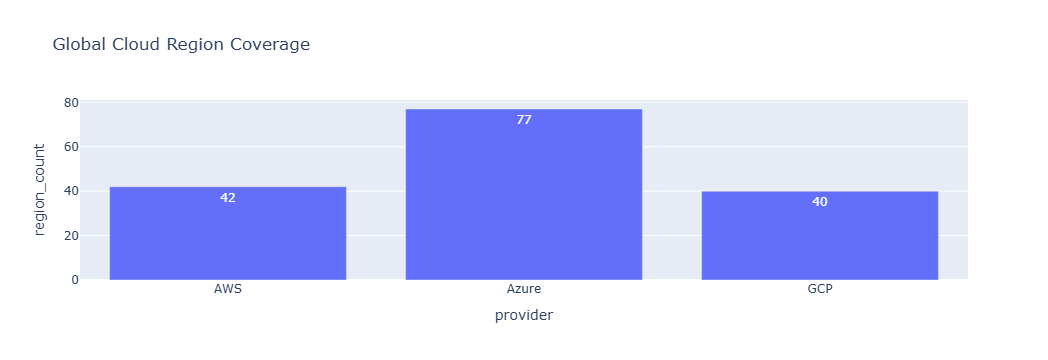

In [18]:
import plotly.express as px

fig = px.bar(
    region_summary,
    x="provider",
    y="region_count",
    title="Global Cloud Region Coverage",
    text="region_count"
)

fig.show()

In [21]:
all_regions = pd.concat(
    [
        aws_regions_df,
        azure_regions_df,
        gcp_regions_df
    ],
    ignore_index=True
)

all_regions.shape

(159, 2)

In [22]:
all_regions.head()

,provider,region_code
0,AWS,af-south-1
1,AWS,ap-east-1
2,AWS,ap-east-2
3,AWS,ap-northeast-1
4,AWS,ap-northeast-2


In [23]:
region_summary = (
    all_regions
    .groupby("provider")
    .agg(
        region_count=("region_code", "nunique")
    )
    .reset_index()
    .sort_values("region_count", ascending=False)
)

region_summary

,provider,region_count
1,Azure,77
0,AWS,42
2,GCP,40


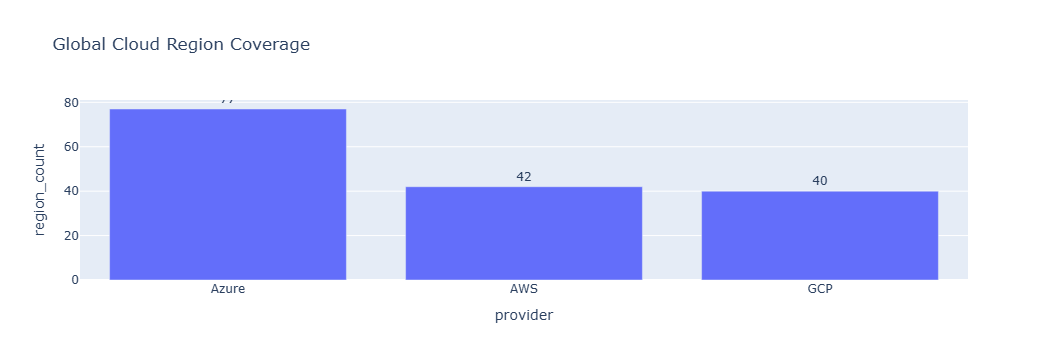

In [24]:
fig = px.bar(
    region_summary,
    x="provider",
    y="region_count",
    text="region_count",
    title="Global Cloud Region Coverage"
)

fig.update_traces(
    textposition="outside"
)

fig.show()

In [25]:
all_regions.to_csv(
    "global_region_detail.csv",
    index=False
)

region_summary.to_csv(
    "global_region_summary.csv",
    index=False
)